# Solutions · 17 · Gaussian processes and stationary time series

Worked solutions to the exercises of [notebook 17](../notebooks/17_gaussian_processes_and_time_series.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import gaussian as gp, timeseries as ts, datasets
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Exercise 1

Sample a Matern 5/2 process on 2^14 points of [0, 100] by circulant embedding (pad if needed) and estimate its variogram; compare with the theoretical one.

padding 0: embedding valid; 20 paths of 16384 points


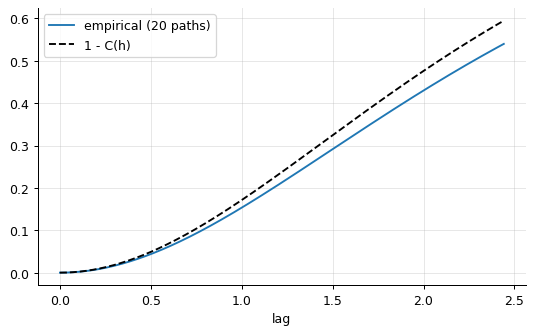

In [2]:
n, L_dom, ell = 2**14, 100.0, 2.0
h = L_dom / n
for pad in (0, n // 2, n):
    try:
        acov = gp.matern52(0, np.arange(n + pad) * h, ell=ell)
        X = gp.circulant_embedding(acov, 20, R(1), pad=pad)["X"]
        print(f"padding {pad}: embedding valid; {X.shape[0]} paths of {X.shape[1]} points"); break
    except ValueError as e:
        print(f"padding {pad}: {e}")
vg = gp.empirical_variogram(X, 400)
lags = np.arange(401) * h
plt.plot(lags, vg, label="empirical (20 paths)"); plt.plot(lags, 1 - gp.matern52(0, lags, ell=ell), "k--", label="1 - C(h)"); plt.legend(); plt.xlabel("lag"); plt.show()

On [0, 100] with ℓ = 2 the window is fifty correlation lengths long, and the minimal embedding is already
non-negative definite (the covariance has decayed to ~10⁻²⁰ at half the window); on a shorter window padding
would be needed. The variogram of twenty paths follows 1 − C(h) and levels off at the variance.

## Exercise 2

Fit AR models to the log-returns of `prices.csv` and to their squares. Are the returns uncorrelated (Ljung-Box)? Are the squared returns? What does that say about the regime change?

In [3]:
pr = pd.read_csv(datasets.path("prices.csv"), comment="#")
lr = np.diff(np.log(pr.close.to_numpy()))
print(f"log-returns: Ljung-Box (20 lags) p = {ts.ljung_box(lr, 20)['p_value']:.3f}; AIC order {ts.select_ar_order(lr, 10)['p']}")
sq = (lr - lr.mean()) ** 2
print(f"squared returns: Ljung-Box p = {ts.ljung_box(sq, 20)['p_value']:.2e}")
print(f"squared returns within each regime: p = {ts.ljung_box(sq[:1000], 20)['p_value']:.3f} and {ts.ljung_box(sq[1000:], 20)['p_value']:.3f}")

log-returns: Ljung-Box (20 lags) p = 0.653; AIC order 1
squared returns: Ljung-Box p = 3.86e-65
squared returns within each regime: p = 0.229 and 0.680


The returns themselves are uncorrelated (as GBM says), but their squares are not - over the whole record.
Within each regime they are, so the "volatility clustering" here is entirely the regime change: a slowly
varying volatility makes squared returns autocorrelated. In real markets volatility varies continuously and
GARCH or stochastic-volatility models describe it.

## Exercise 3

**Implement it yourself:** write circulant embedding for a stationary covariance from scratch (FFT of the first row, check of the eigenvalues, complex white noise) and check the sample covariance of 10^4 paths.

In [4]:
def circulant(acov, n_paths, g):
    c = np.asarray(acov, float); row = np.r_[c, c[-2:0:-1]]; m = len(row)
    lam = np.fft.fft(row).real
    assert lam.min() > -1e-10 * lam.max(), "embedding not non-negative definite"
    Z = g.standard_normal((n_paths, m)) + 1j * g.standard_normal((n_paths, m))
    Y = np.fft.fft(np.sqrt(np.maximum(lam, 0) / m) * Z, axis=1)
    return np.vstack([Y.real, Y.imag])[:, : len(c)]
t = np.arange(200) * 0.05
X = circulant(gp.exponential(0, t, ell=0.5), 5000, R(2))
print("sample covariance at lags 0, 5, 20:", np.round(np.cov(X[:, [0, 5, 20]].T)[0], 3), " theory", np.round(gp.exponential(0, t[[0, 5, 20]], ell=0.5), 3))

sample covariance at lags 0, 5, 20: [0.996 0.608 0.149]  theory [1.    0.607 0.135]


A circulant matrix is diagonalised by the Fourier matrix, its eigenvalues are the FFT of its first row, and
F diag(√λ/√m) Z with complex white noise Z has covariance equal to the circulant - whose top-left n × n block is
the wanted Toeplitz covariance. Real and imaginary parts are two independent samples.